<a href="https://www.kaggle.com/code/sonawanelalitsunil/covid-19-worldwide-data-ml-54?scriptVersionId=234367850" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/covid-19-global-dataset/synthetic_covid19_data.csv


## Title: COVID-19 Worldwide Data

#### Description: Comprehensive dataset of global COVID-19 statistics including cases, fatalities, and testing by country.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/covid-19-global-dataset/synthetic_covid19_data.csv')

In [3]:
df.head()

,date,continent,location,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,positive_rate,...,stringency_index,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence
0,2021-11-19,Asia,India,6423388,2490,107051,323,60016385,7386,0.904377,...,69.259331,1241418161,67.394702,49.883751,8.649395,16.052063,44313.199955,20.827286,177.832655,16.296474
1,2021-09-12,North America,Russia,6550634,6980,481184,697,28666409,6862,0.525850,...,7.185287,114516392,694.409929,30.126823,8.957854,4.423022,8196.945011,20.478579,470.991420,8.579170
2,2020-04-20,Europe,Canada,4304572,9134,15116,325,80352550,40108,0.791575,...,14.823246,1152898402,784.464729,22.648063,9.336778,18.776372,52607.000057,11.924664,415.880908,14.989789
3,2022-10-16,Asia,Germany,2234489,7661,20045,624,89212990,91788,0.115291,...,70.007502,1342525124,403.467508,42.951109,5.321894,10.526520,23297.985037,4.591400,643.510444,18.084096
4,2021-05-15,Europe,USA,9958614,1724,419543,824,5364240,75023,0.927643,...,28.972334,744943966,182.869692,26.414731,19.321761,15.889173,56126.828895,5.431330,451.846790,5.971409


In [4]:
df.tail()

,date,continent,location,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,positive_rate,...,stringency_index,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence
2995,2022-11-09,Asia,France,7085904,1537,380572,854,38716025,79552,0.197973,...,98.890603,629900904,764.616886,33.458451,10.699616,9.350358,2098.653639,4.346562,493.921655,6.836992
2996,2020-01-24,North America,India,6699744,397,277354,353,27906787,38233,0.920767,...,26.402506,970688939,691.752546,43.324178,15.298106,8.681226,4533.613663,30.872835,438.493670,17.708803
2997,2021-02-08,Asia,France,9024327,5680,442726,74,88886044,22695,0.441796,...,16.666702,146193923,650.365284,31.532917,11.588981,19.658565,63901.494497,16.760837,777.073028,3.726194
2998,2020-02-05,Asia,India,2801445,9355,364225,801,63500569,90488,0.742791,...,54.633328,485038295,552.083660,26.648227,5.098328,10.351321,25728.132347,33.450083,198.230609,11.864297
2999,2021-06-21,Europe,Canada,9196866,4825,169746,928,48153647,42734,0.546996,...,55.189039,502986611,484.403500,28.728532,5.813562,14.526652,21578.044401,28.410705,480.571347,10.892834


In [5]:
df.describe()

,total_cases,new_cases,total_deaths,new_deaths,total_tests,new_tests,positive_rate,tests_per_case,total_vaccinations,people_vaccinated,...,stringency_index,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence
count,3.000000e+03,3000.000000,3000.000000,3000.000000,3.000000e+03,3000.00000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,...,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,4.970822e+06,4933.382667,252170.073000,501.944333,4.990409e+07,49176.34200,0.502899,246.313132,5.054665e+07,3.944236e+07,...,49.420508,7.000848e+08,504.417978,34.954233,14.947891,11.385179,35872.847690,25.096407,452.949274,10.436695
std,2.840551e+06,2862.387046,142288.916742,286.865451,2.938662e+07,29335.17051,0.286454,142.898800,2.888088e+07,2.314784e+07,...,28.926971,4.085710e+08,287.992252,8.678754,5.777631,4.903229,19925.718629,14.343835,202.618334,5.423249
min,1.729700e+04,1.000000,74.000000,0.000000,4.212000e+03,5.00000,0.000119,0.087758,4.554000e+03,6.170000e+02,...,0.010237,1.110996e+06,10.588810,20.000502,5.001872,3.001780,1026.731495,0.056399,100.005903,1.011965
25%,2.602631e+06,2518.500000,131482.500000,252.750000,2.414482e+07,22645.25000,0.253634,121.780384,2.499653e+07,1.881256e+07,...,24.258523,3.408214e+08,258.464713,27.473284,9.825665,7.131367,18274.354626,13.076350,278.907744,5.905785
50%,4.944837e+06,4843.500000,255026.000000,506.000000,5.045845e+07,49491.50000,0.509628,244.688678,5.187611e+07,3.994068e+07,...,49.527373,6.956387e+08,499.912506,34.892248,14.897659,11.363021,36849.521790,24.942092,455.707196,10.179357
75%,7.356497e+06,7381.250000,373209.500000,749.000000,7.490383e+07,75177.50000,0.746760,364.518071,7.551452e+07,5.936983e+07,...,74.679065,1.057497e+09,757.980516,42.511328,20.054738,15.585339,52862.615194,37.605693,631.834708,15.075605
max,9.993726e+06,9993.000000,499920.000000,998.000000,9.992758e+07,99987.00000,0.999893,499.361627,9.998511e+07,7.998922e+07,...,99.980848,1.398727e+09,998.762017,49.999164,24.999139,19.994429,69989.049734,49.988448,799.957787,19.994108


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     3000 non-null   object 
 1   continent                3000 non-null   object 
 2   location                 3000 non-null   object 
 3   total_cases              3000 non-null   int64  
 4   new_cases                3000 non-null   int64  
 5   total_deaths             3000 non-null   int64  
 6   new_deaths               3000 non-null   int64  
 7   total_tests              3000 non-null   int64  
 8   new_tests                3000 non-null   int64  
 9   positive_rate            3000 non-null   float64
 10  tests_per_case           3000 non-null   float64
 11  total_vaccinations       3000 non-null   int64  
 12  people_vaccinated        3000 non-null   int64  
 13  people_fully_vaccinated  3000 non-null   int64  
 14  hosp_patients           

In [7]:
df.isnull().sum()

date                       0
continent                  0
location                   0
total_cases                0
new_cases                  0
total_deaths               0
new_deaths                 0
total_tests                0
new_tests                  0
positive_rate              0
tests_per_case             0
total_vaccinations         0
people_vaccinated          0
people_fully_vaccinated    0
hosp_patients              0
icu_patients               0
reproduction_rate          0
stringency_index           0
population                 0
population_density         0
median_age                 0
aged_65_older              0
aged_70_older              0
gdp_per_capita             0
extreme_poverty            0
cardiovasc_death_rate      0
diabetes_prevalence        0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(3000, 27)

In [10]:
df.dtypes

date                        object
continent                   object
location                    object
total_cases                  int64
new_cases                    int64
total_deaths                 int64
new_deaths                   int64
total_tests                  int64
new_tests                    int64
positive_rate              float64
tests_per_case             float64
total_vaccinations           int64
people_vaccinated            int64
people_fully_vaccinated      int64
hosp_patients                int64
icu_patients                 int64
reproduction_rate          float64
stringency_index           float64
population                   int64
population_density         float64
median_age                 float64
aged_65_older              float64
aged_70_older              float64
gdp_per_capita             float64
extreme_poverty            float64
cardiovasc_death_rate      float64
diabetes_prevalence        float64
dtype: object

In [11]:
df.columns

Index(['date', 'continent', 'location', 'total_cases', 'new_cases',
       'total_deaths', 'new_deaths', 'total_tests', 'new_tests',
       'positive_rate', 'tests_per_case', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'hosp_patients',
       'icu_patients', 'reproduction_rate', 'stringency_index', 'population',
       'population_density', 'median_age', 'aged_65_older', 'aged_70_older',
       'gdp_per_capita', 'extreme_poverty', 'cardiovasc_death_rate',
       'diabetes_prevalence'],
      dtype='object')

## data visualizations

In [12]:
# Aesthetic setup
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [13]:
# Drop rows with missing location
df = df.dropna(subset=['location'])

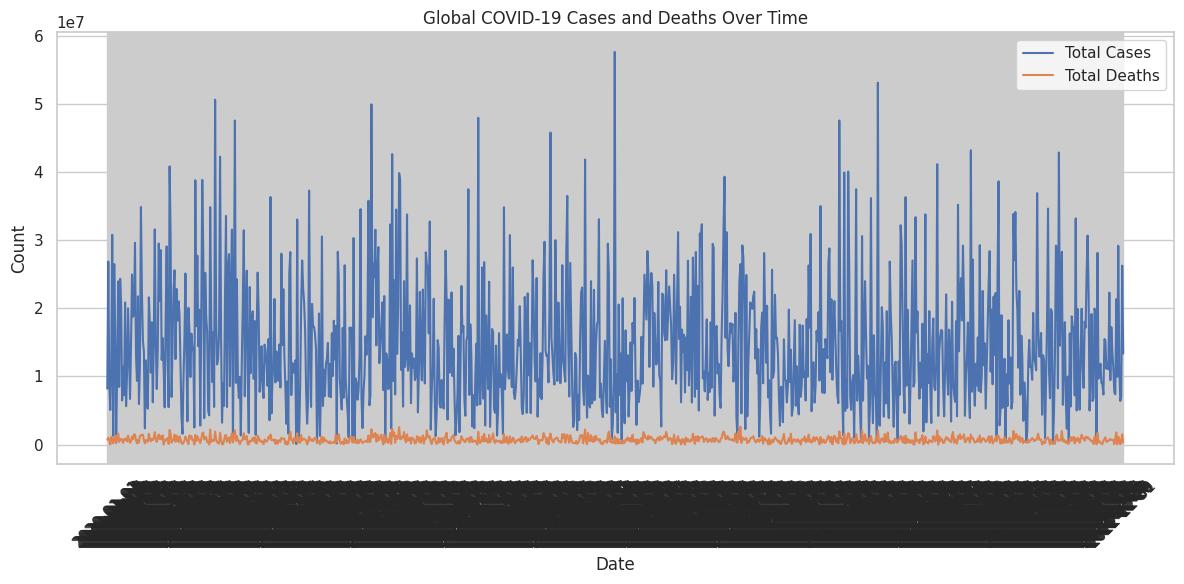

In [14]:
global_df = df.groupby('date')[['total_cases', 'total_deaths']].sum().reset_index()

plt.plot(global_df['date'], global_df['total_cases'], label='Total Cases')
plt.plot(global_df['date'], global_df['total_deaths'], label='Total Deaths')
plt.title('Global COVID-19 Cases and Deaths Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


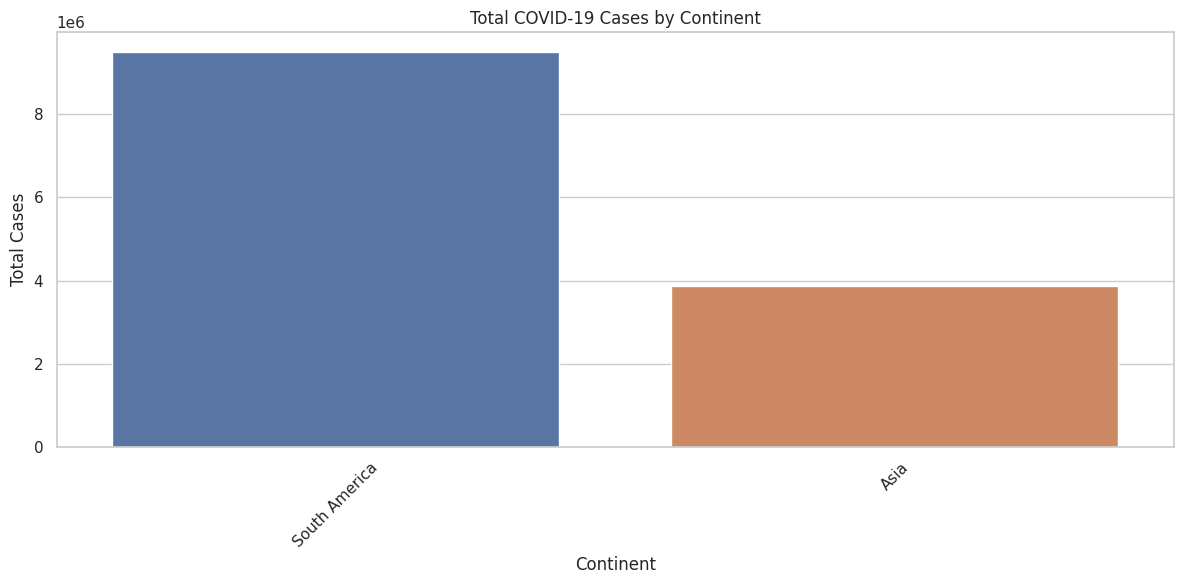

In [15]:
latest_date = df['date'].max()
latest = df[df['date'] == latest_date]

sns.barplot(data=latest, x='continent', y='total_cases', estimator=sum, errorbar=None)
plt.title('Total COVID-19 Cases by Continent')
plt.ylabel('Total Cases')
plt.xlabel('Continent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


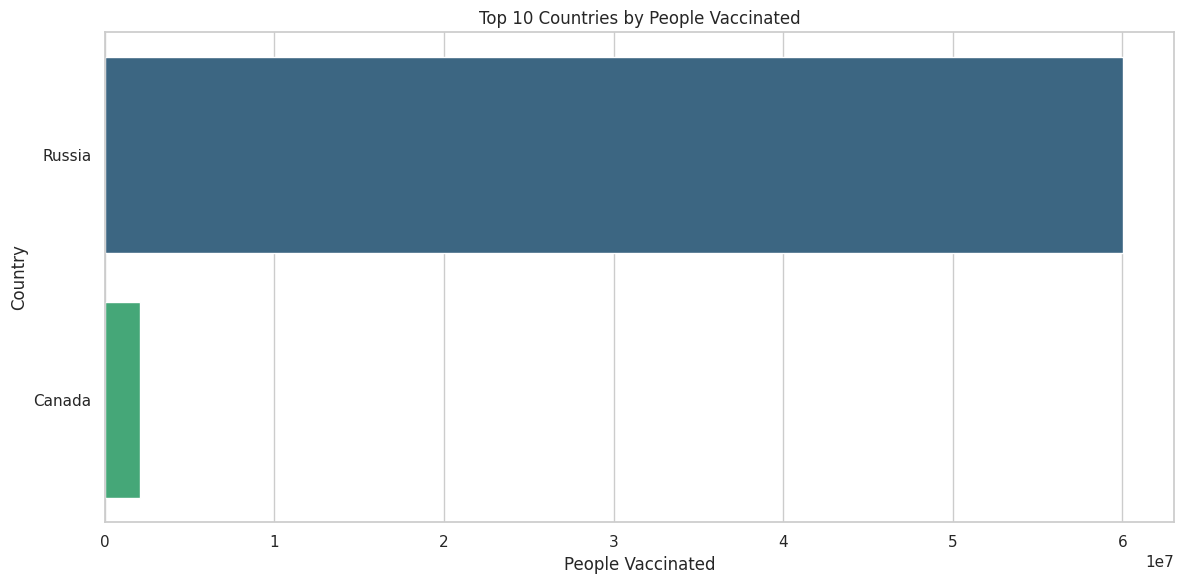

In [16]:
vacc = latest[['location', 'people_vaccinated']].dropna().sort_values(by='people_vaccinated', ascending=False).head(10)

sns.barplot(data=vacc, x='people_vaccinated', y='location', palette='viridis')
plt.title('Top 10 Countries by People Vaccinated')
plt.xlabel('People Vaccinated')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


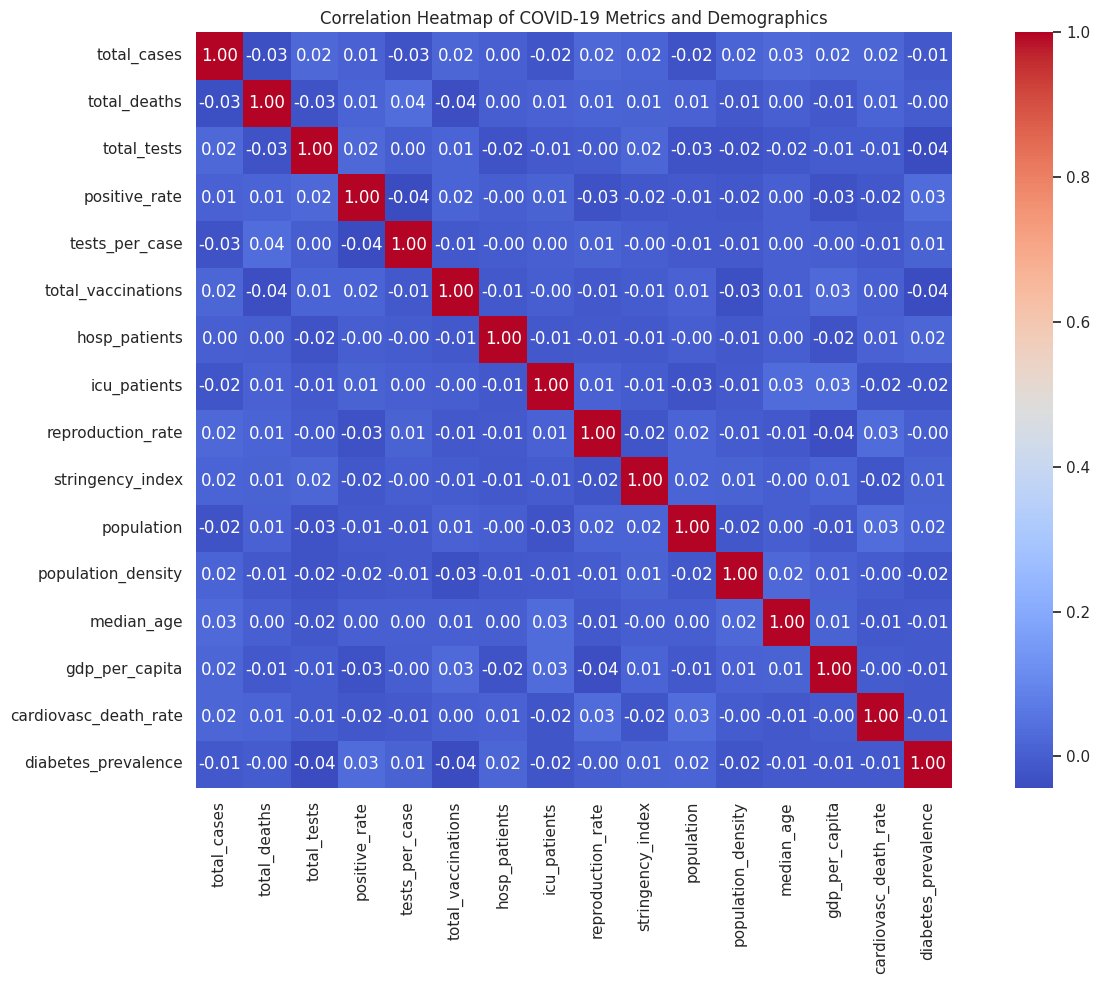

In [17]:
num_cols = ['total_cases', 'total_deaths', 'total_tests', 'positive_rate',
            'tests_per_case', 'total_vaccinations', 'hosp_patients',
            'icu_patients', 'reproduction_rate', 'stringency_index',
            'population', 'population_density', 'median_age', 'gdp_per_capita',
            'cardiovasc_death_rate', 'diabetes_prevalence']

corr = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", square=True)
plt.title('Correlation Heatmap of COVID-19 Metrics and Demographics')
plt.tight_layout()
plt.show()


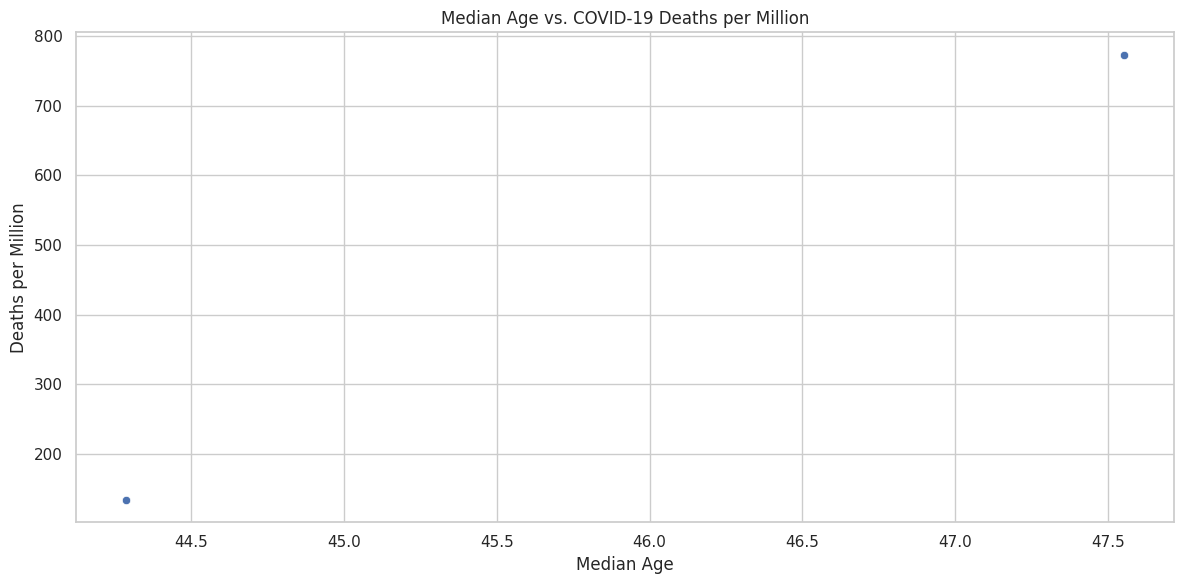

In [18]:
age_vs_deaths = latest[['location', 'median_age', 'total_deaths', 'population']].dropna()
age_vs_deaths['deaths_per_million'] = (age_vs_deaths['total_deaths'] / age_vs_deaths['population']) * 1e6

sns.scatterplot(data=age_vs_deaths, x='median_age', y='deaths_per_million')
plt.title('Median Age vs. COVID-19 Deaths per Million')
plt.xlabel('Median Age')
plt.ylabel('Deaths per Million')
plt.tight_layout()
plt.show()


## Predictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [20]:
# 2. Drop rows with missing target
df = df.dropna(subset=['total_deaths'])

In [21]:
# 3. Create binary target (classification): 0 = Low, 1 = High
median_death = df['total_deaths'].median()
df['death_level'] = df['total_deaths'].apply(lambda x: 1 if x >= median_death else 0)

In [22]:
# 4. Drop columns not needed or causing leakage
drop_cols = ['date', 'location', 'total_deaths', 'new_deaths']  # date is time-based, total_deaths is used as target
df = df.drop(columns=drop_cols)

In [23]:
# 5. Fill missing values
df.fillna(df.median(numeric_only=True), inplace=True)


In [24]:
# 6. Label encode categorical columns
le = LabelEncoder()
df['continent'] = le.fit_transform(df['continent'].astype(str))

In [25]:
# 7. Define features and target
X = df.drop('death_level', axis=1)
y = df['death_level']

In [26]:
# 8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# 9. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}


In [29]:
for name, model in models.items():
    print(f"\n📌 Training: {name}")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print("🧾 Classification Report:")
    print(classification_report(y_test, y_pred))
    print("🔍 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


📌 Training: Logistic Regression
✅ Accuracy: 0.5183
🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.51      0.52       304
           1       0.51      0.53      0.52       296

    accuracy                           0.52       600
   macro avg       0.52      0.52      0.52       600
weighted avg       0.52      0.52      0.52       600

🔍 Confusion Matrix:
[[155 149]
 [140 156]]

📌 Training: Decision Tree
✅ Accuracy: 0.5250
🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.52      0.52       304
           1       0.52      0.53      0.53       296

    accuracy                           0.53       600
   macro avg       0.53      0.53      0.52       600
weighted avg       0.53      0.53      0.52       600

🔍 Confusion Matrix:
[[157 147]
 [138 158]]

📌 Training: Random Forest
✅ Accuracy: 0.5350
🧾 Classification Report:
              precision    recall  f1-sco

## THank you..pls upvote!!!